### Student Name: Feliciann Elliot
### Course: MAI5301 - Foundations Of Large Language Models
### Activity: Assigment #5

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import requests
import zipfile
import os

## Preparing the dataset

In [ ]:
# Download zip
url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "spam.zip"

response = requests.get(url)
with open(zip_path, "wb") as f:
    f.write(response.content)

# Unzip
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("data")

# Rename file to .tsv
os.rename("data/SMSSpamCollection", "data/SMSSpamCollection.tsv")

print("Done. Data ready at data/SMSSpamCollection.tsv")

Done. Data ready at data/SMSSpamCollection.tsv


In [ ]:
!ls -l data/

total 476
-rw-r--r-- 1 root root   5868 Mar 22 20:15 readme
-rw-r--r-- 1 root root 477907 Mar 22 20:15 SMSSpamCollection.tsv


In [ ]:
!head -n 8 data/SMSSpamCollection.tsv

ham	Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
ham	Ok lar... Joking wif u oni...
spam	Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
ham	U dun say so early hor... U c already then say...
ham	Nah I don't think he goes to usf, he lives around here though
spam	FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, £1.50 to rcv
ham	Even my brother is not like to speak with me. They treat me like aids patent.
ham	As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has been set as your callertune for all Callers. Press *9 to copy your friends Callertune


Dataset shape: (5572, 2)

Class distribution:
Label
ham     4825
spam     747
Name: count, dtype: int64

Percentage:
Label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


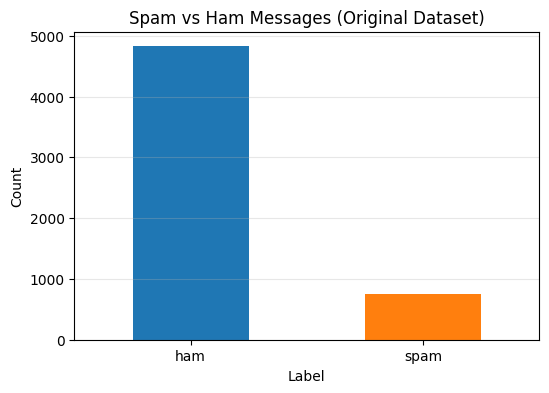

In [ ]:
# Load the data
df = pd.read_csv(
    "data/SMSSpamCollection.tsv",
    sep="\t",
    header=None,
    names=["Label", "Text"]
)

# Quick overview
print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df["Label"].value_counts())
print("\nPercentage:")
print(df["Label"].value_counts(normalize=True) * 100)

# Visualize
plt.figure(figsize=(6, 4))
df["Label"].value_counts().plot(kind="bar", color=["#1f77b4", "#ff7f0e"])
plt.title("Spam vs Ham Messages (Original Dataset)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

## Creating a balanced dataset

In [ ]:
# Create balanced version (equal number of ham and spam)
num_spam = df[df["Label"] == "spam"].shape[0]   # 747
ham_subset = df[df["Label"] == "ham"].sample(n=num_spam, random_state=123)

balanced_df = pd.concat([ham_subset, df[df["Label"] == "spam"]])

# Shuffle just in case
balanced_df = balanced_df.sample(frac=1, random_state=123).reset_index(drop=True)

# Map labels to 0/1 for training
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})

print("Balanced dataset shape:", balanced_df.shape)
print("\nClass distribution in balanced set:")
print(balanced_df["Label"].value_counts())
print("\nFirst 5 rows of balanced_df:")
print(balanced_df.head())

# Optional: save to csv if you want to inspect later
balanced_df.to_csv("data/balanced_sms_spam.csv", index=False)
print("\nSaved balanced version → data/balanced_sms_spam.csv")

Balanced dataset shape: (1494, 2)

Class distribution in balanced set:
Label
0    747
1    747
Name: count, dtype: int64

First 5 rows of balanced_df:
   Label                                               Text
0      0                Dude how do you like the buff wind.
1      0  Tessy..pls do me a favor. Pls convey my birthd...
2      1  Reminder: You have not downloaded the content ...
3      1  Got what it takes 2 take part in the WRC Rally...
4      1  Shop till u Drop, IS IT YOU, either 10K, 5K, £...

Saved balanced version → data/balanced_sms_spam.csv


In [ ]:
def random_split(df, train_frac=0.7, val_frac=0.1):
    # Shuffle the DataFrame
    df_shuffled = df.sample(frac=1, random_state=123).reset_index(drop=True)

    # Calculate split points
    n = len(df_shuffled)
    train_end = int(n * train_frac)
    val_end = train_end + int(n * val_frac)

    train_df = df_shuffled[:train_end]
    val_df   = df_shuffled[train_end:val_end]
    test_df  = df_shuffled[val_end:]

    return train_df, val_df, test_df


# Perform the split
train_df, val_df, test_df = random_split(balanced_df, train_frac=0.7, val_frac=0.1)

print(f"Train size: {len(train_df):4d} rows  ({len(train_df)/len(balanced_df):.1%})")
print(f"Val   size: {len(val_df):4d} rows  ({len(val_df)/len(balanced_df):.1%})")
print(f"Test  size: {len(test_df):4d} rows  ({len(test_df)/len(balanced_df):.1%})")

# Quick class balance check in each split
print("\nTrain class balance:\n", train_df["Label"].value_counts())
print("\nVal   class balance:\n", val_df["Label"].value_counts())
print("\nTest  class balance:\n", test_df["Label"].value_counts())

# Save to disk (in your data/ folder)
train_df.to_csv("data/train.csv", index=False)
val_df.to_csv("data/validation.csv", index=False)
test_df.to_csv("data/test.csv", index=False)

print("\nSaved:")
print("  → data/train.csv")
print("  → data/validation.csv")
print("  → data/test.csv")

Train size: 1045 rows  (69.9%)
Val   size:  149 rows  (10.0%)
Test  size:  300 rows  (20.1%)

Train class balance:
 Label
0    530
1    515
Name: count, dtype: int64

Val   class balance:
 Label
0    76
1    73
Name: count, dtype: int64

Test  class balance:
 Label
1    159
0    141
Name: count, dtype: int64

Saved:
  → data/train.csv
  → data/validation.csv
  → data/test.csv


## Creating data loaders

In [ ]:
import tiktoken
import torch
from torch.utils.data import Dataset, DataLoader

In [ ]:
# Get the GPT-2 tokenizer (same as used in original GPT-2)
tokenizer = tiktoken.get_encoding("gpt2")
print("Tokenizer ready. Vocab size:", tokenizer.n_vocab)

class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):
        self.data = pd.read_csv(csv_file)
        self.tokenizer = tokenizer
        self.pad_token_id = pad_token_id

        # Pre-tokenize all texts once (faster during training)
        self.encoded_texts = [tokenizer.encode(text) for text in self.data["Text"]]

        # Determine max_length: either user-provided or longest in dataset
        if max_length is None:
            self.max_length = self._find_longest_encoded_length()
        else:
            self.max_length = max_length
            # Truncate if longer than requested max_length
            self.encoded_texts = [enc[:self.max_length] for enc in self.encoded_texts]

        # Pad all sequences to max_length
        self.encoded_texts = [
            enc + [pad_token_id] * (self.max_length - len(enc))
            for enc in self.encoded_texts
        ]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        encoded = self.encoded_texts[idx]
        label = self.data.iloc[idx]["Label"]
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )

    def _find_longest_encoded_length(self):
        # Simple loop version (as in the book)
        if not self.encoded_texts:
            return 0
        return max(len(enc) for enc in self.encoded_texts)

Tokenizer ready. Vocab size: 50257


In [ ]:
# Quick test: create train dataset and check its max length
train_dataset = SpamDataset(
    csv_file="data/train.csv",
    tokenizer=tokenizer,
    max_length=None   # auto-detect longest
)

print("\nTrain dataset:")
print("  Number of examples:", len(train_dataset))
print("  Max sequence length (auto-detected):", train_dataset.max_length)
print("  Example labels:", [train_dataset[i][1].item() for i in range(5)])


Train dataset:
  Number of examples: 1045
  Max sequence length (auto-detected): 120
  Example labels: [0, 1, 1, 1, 0]


In [ ]:
# Re-use the max_length from train dataset
max_length = train_dataset.max_length
print(f"Using fixed max_length = {max_length} for all splits\n")

# Create datasets
val_dataset = SpamDataset(
    csv_file="data/validation.csv",
    tokenizer=tokenizer,
    max_length=max_length,
    pad_token_id=50256
)

test_dataset = SpamDataset(
    csv_file="data/test.csv",
    tokenizer=tokenizer,
    max_length=max_length,
    pad_token_id=50256
)

# DataLoaders
batch_size = 8
num_workers = 0   # 0 is safest on Colab unless you have many cores

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    drop_last=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    drop_last=False
)

print("DataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val   batches: {len(val_loader)}")
print(f"  Test  batches: {len(test_loader)}")

# Quick sanity check: look at one batch from train
print("\nExample batch from train_loader:")
for input_batch, target_batch in train_loader:
    print("Input shape: ", input_batch.shape)     # should be [8, 120]
    print("Labels:     ", target_batch.tolist())
    break   # only show first batch

Using fixed max_length = 120 for all splits

DataLoaders created:
  Train batches: 130
  Val   batches: 19
  Test  batches: 38

Example batch from train_loader:
Input shape:  torch.Size([8, 120])
Labels:      [0, 1, 1, 0, 0, 0, 0, 1]


## Loading and modifying GPT-2 for classification

In [ ]:
from gpt_download import download_and_load_gpt2   
from previous_chapters import GPTModel, load_weights_into_gpt  


MODEL_CHOICE = "gpt2-small (124M)"

model_configs = {
    "gpt2-small (124M)":  {"emb_dim": 768,  "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)":  {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
}

BASE_CONFIG = {
    "vocab_size": 50257,
    "context_length": 1024,
    "drop_rate": 0.0,
    "qkv_bias": True
}

BASE_CONFIG.update(model_configs[MODEL_CHOICE])

# Check that our dataset fits
assert train_dataset.max_length <= BASE_CONFIG["context_length"], \
    f"Max length {train_dataset.max_length} > model context {BASE_CONFIG['context_length']}"

print(f"Loading {MODEL_CHOICE} configuration...")

# Download weights (if not already present)
model_size = MODEL_CHOICE.split(" ")[-1].strip("()")
settings, params = download_and_load_gpt2(
    model_size=model_size,
    models_dir="gpt2_weights"   # folder will be created
)

# Create model + load pretrained weights
model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
print("Pretrained weights loaded.")

num_classes = 2

# Replace the original language modeling head
model.out_head = torch.nn.Linear(
    in_features=BASE_CONFIG["emb_dim"],
    out_features=num_classes,
    bias=False   # common for classification heads
)

# Move to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Model moved to: {device}")
print(f"New output head shape: {model.out_head.weight.shape}")  # should be [2, 768]

# Freezing strategy (as in the book)
# Freeze all parameters first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze only the last transformer block + final norm + new head
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True

for param in model.final_norm.parameters():
    param.requires_grad = True

# Count trainable parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print(f"Trainable parameters: {trainable_params:,} / {total_params:,} "
      f"({trainable_params / total_params:.2%})")

Loading gpt2-small (124M) configuration...


checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 135kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:00<00:00, 2.84MiB/s]
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 280kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [00:32<00:00, 15.3MiB/s]
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 10.4MiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:00<00:00, 2.23MiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 2.30MiB/s]


Pretrained weights loaded.
Model moved to: cuda
New output head shape: torch.Size([2, 768])
Trainable parameters: 7,089,408 / 124,441,344 (5.70%)


## Training the classifier

In [ ]:
import torch.nn.functional as F

def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct_predictions, num_examples = 0, 0

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch = input_batch.to(device)
            target_batch = target_batch.to(device)

            with torch.no_grad():
                logits = model(input_batch)[:, -1, :]          # last token's logits
            predicted_labels = torch.argmax(logits, dim=-1)

            num_examples += predicted_labels.shape[0]
            correct_predictions += (predicted_labels == target_batch).sum().item()
        else:
            break

    return correct_predictions / num_examples


def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)[:, -1, :]                  # last token
    loss = F.cross_entropy(logits, target_batch)
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    model.eval()
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches


# Quick test: check initial (untrained) performance
torch.manual_seed(123)

print("Initial performance (before any training):")
train_acc = calc_accuracy_loader(train_loader, model, device, num_batches=10)
val_acc   = calc_accuracy_loader(val_loader,   model, device, num_batches=10)
test_acc  = calc_accuracy_loader(test_loader,  model, device)

print(f"  Train accuracy (first 10 batches): {train_acc:.3f}")
print(f"  Val   accuracy (first 10 batches): {val_acc:.3f}")
print(f"  Test  accuracy (full):            {test_acc:.3f}")

Initial performance (before any training):
  Train accuracy (first 10 batches): 0.550
  Val   accuracy (first 10 batches): 0.463
  Test  accuracy (full):            0.470


In [ ]:
print(device)

cuda


In [ ]:
import time
import torch.optim as optim

def train_classifier_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs, eval_freq, eval_iter
):
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    examples_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()

            examples_seen += input_batch.shape[0]
            global_step += 1

            # Periodic evaluation
            if global_step % eval_freq == 0:
                train_loss = calc_loss_loader(
                    train_loader, model, device, num_batches=eval_iter
                )
                val_loss = calc_loss_loader(
                    val_loader, model, device, num_batches=eval_iter
                )
                print(f"Ep {epoch+1:02d} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f} | Val loss {val_loss:.3f}")
                train_losses.append(train_loss)
                val_losses.append(val_loss)

        # Epoch-end accuracy
        train_acc = calc_accuracy_loader(train_loader, model, device, num_batches=eval_iter)
        val_acc   = calc_accuracy_loader(val_loader,   model, device, num_batches=eval_iter)
        print(f"Epoch {epoch+1:02d} accuracy → Train: {train_acc:.3f} | Val: {val_acc:.3f}")
        train_accs.append(train_acc)
        val_accs.append(val_acc)

    return train_losses, val_losses, train_accs, val_accs, examples_seen

#Training
torch.manual_seed(123)

optimizer = optim.AdamW(
    model.parameters(),
    lr=5e-5,
    weight_decay=0.1
)

num_epochs   = 5
eval_freq    = 50     # evaluate every 50 steps
eval_iter    = 5      # only use 5 batches for quick loss/acc estimates

print("Starting fine-tuning...\n")

start_time = time.time()

train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_simple(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs=num_epochs,
    eval_freq=eval_freq,
    eval_iter=eval_iter
)

end_time = time.time()
minutes = (end_time - start_time) / 60

print(f"\nTraining finished in {minutes:.1f} minutes.")
print(f"Total examples processed: {examples_seen:,}")

Starting fine-tuning...

Ep 01 (Step 000000): Train loss 3.546 | Val loss 3.978
Ep 01 (Step 000050): Train loss 0.595 | Val loss 0.575
Ep 01 (Step 000100): Train loss 0.391 | Val loss 0.403
Epoch 01 accuracy → Train: 0.875 | Val: 0.900
Ep 02 (Step 000150): Train loss 0.369 | Val loss 0.270
Ep 02 (Step 000200): Train loss 0.255 | Val loss 0.157
Ep 02 (Step 000250): Train loss 0.118 | Val loss 0.116
Epoch 02 accuracy → Train: 1.000 | Val: 0.975
Ep 03 (Step 000300): Train loss 0.228 | Val loss 0.111
Ep 03 (Step 000350): Train loss 0.291 | Val loss 0.188
Epoch 03 accuracy → Train: 0.975 | Val: 0.950
Ep 04 (Step 000400): Train loss 0.151 | Val loss 0.054
Ep 04 (Step 000450): Train loss 0.110 | Val loss 0.152
Ep 04 (Step 000500): Train loss 0.041 | Val loss 0.061
Epoch 04 accuracy → Train: 1.000 | Val: 0.975
Ep 05 (Step 000550): Train loss 0.061 | Val loss 0.030
Ep 05 (Step 000600): Train loss 0.140 | Val loss 0.042
Epoch 05 accuracy → Train: 1.000 | Val: 0.950

Training finished in 1.0 minu

In [ ]:
print("Final full-dataset evaluation:")

train_acc_full = calc_accuracy_loader(train_loader, model, device)
val_acc_full   = calc_accuracy_loader(val_loader,   model, device)
test_acc_full  = calc_accuracy_loader(test_loader,  model, device)

print(f"Train accuracy (full): {train_acc_full*100:.2f}%")
print(f"Val   accuracy (full): {val_acc_full*100:.2f}%")
print(f"Test  accuracy (full): {test_acc_full*100:.2f}%")

Final full-dataset evaluation:
Train accuracy (full): 97.50%
Val   accuracy (full): 98.66%
Test  accuracy (full): 96.33%


## Plotting training progress (loss and accuracy)

In [ ]:
import numpy as np

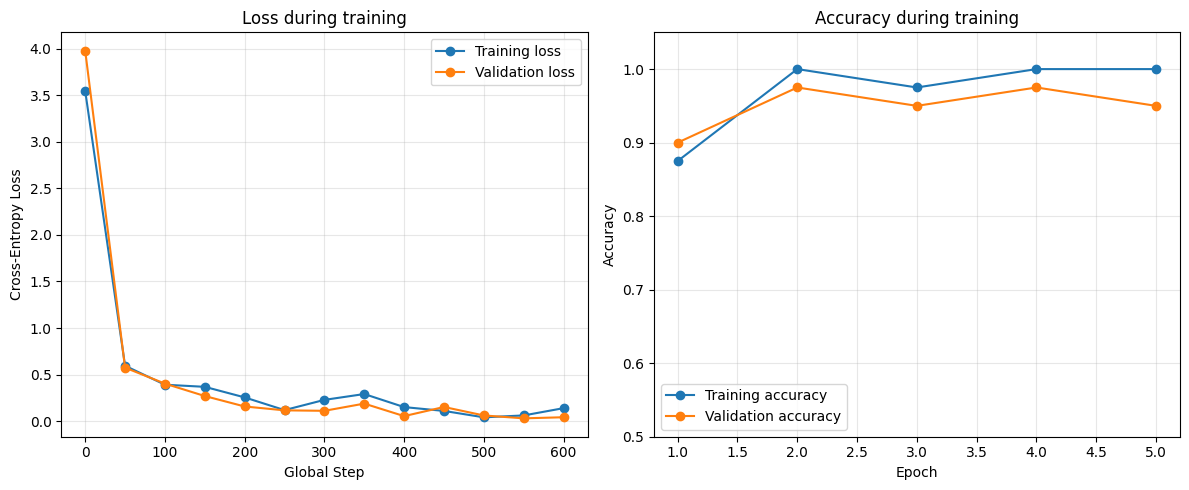

Final values:
  Last train loss:   0.1395
  Last val   loss:   0.0418
  Last train acc:    1.0000
  Last val   acc:    0.9500


In [ ]:
epochs = np.arange(1, len(train_accs) + 1)
# Create a separate x-axis for losses, which were recorded every `eval_freq` steps
# The number of steps where losses were recorded is len(train_losses)
# The steps start from 0 and increment by eval_freq
loss_steps = np.arange(0, len(train_losses) * eval_freq, eval_freq)

plt.figure(figsize=(12, 5))

# Left: Loss
plt.subplot(1, 2, 1)
plt.plot(loss_steps, train_losses, label='Training loss', marker='o')
plt.plot(loss_steps, val_losses,   label='Validation loss', marker='o')
plt.title('Loss during training')
plt.xlabel('Global Step') # Changed label from Epoch to Global Step
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Right: Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs, label='Training accuracy', marker='o')
plt.plot(epochs, val_accs,   label='Validation accuracy', marker='o')
plt.title('Accuracy during training')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0.5, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Final values:")
print(f"  Last train loss:   {train_losses[-1]:.4f}")
print(f"  Last val   loss:   {val_losses[-1]:.4f}")
print(f"  Last train acc:    {train_accs[-1]:.4f}")
print(f"  Last val   acc:    {val_accs[-1]:.4f}")

## Using the model as a spam classifier (inference)

In [ ]:
# Function to classify new messages
def classify_message(
    text,
    model,
    tokenizer,
    device,
    max_length=120,
    pad_token_id=50256
):
    """
    Classify a single message as 'ham' (0) or 'spam' (1)
    """
    model.eval()

    # Tokenize and prepare input
    encoded = tokenizer.encode(text)

    # Truncate if too long
    if len(encoded) > max_length:
        encoded = encoded[:max_length]

    # Pad
    padded = encoded + [pad_token_id] * (max_length - len(encoded))

    # To tensor + batch dimension
    input_tensor = torch.tensor([padded], dtype=torch.long).to(device)

    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]   # last token logits
        predicted_class = torch.argmax(logits, dim=-1).item()

    label = "spam" if predicted_class == 1 else "ham"
    return label, predicted_class

In [ ]:
# === Test on some example messages ===
examples = [
    "Win a free iPhone 15! Click here now: bit.ly/freeiphone",
    "Hey, are we still meeting at 7pm tonight?",
    "URGENT: Your account has been locked. Verify now to avoid suspension.",
    "Just checking if you received the document I sent yesterday.",
    "Congratulations! You've been selected for a $500 Amazon gift card.",
    "Can you pick up milk on your way home?",
]

print("Inference examples:\n")
for msg in examples:
    label, class_id = classify_message(
        msg,
        model,
        tokenizer,
        device,
        max_length=train_dataset.max_length
    )
    print(f"Message: {msg}")
    print(f"Prediction: {label} (class {class_id})\n")

Inference examples:

Message: Win a free iPhone 15! Click here now: bit.ly/freeiphone
Prediction: spam (class 1)

Message: Hey, are we still meeting at 7pm tonight?
Prediction: ham (class 0)

Message: URGENT: Your account has been locked. Verify now to avoid suspension.
Prediction: ham (class 0)

Message: Just checking if you received the document I sent yesterday.
Prediction: ham (class 0)

Message: Congratulations! You've been selected for a $500 Amazon gift card.
Prediction: spam (class 1)

Message: Can you pick up milk on your way home?
Prediction: ham (class 0)



## Confusion matrix & error analysis on test set

<Figure size 600x500 with 0 Axes>

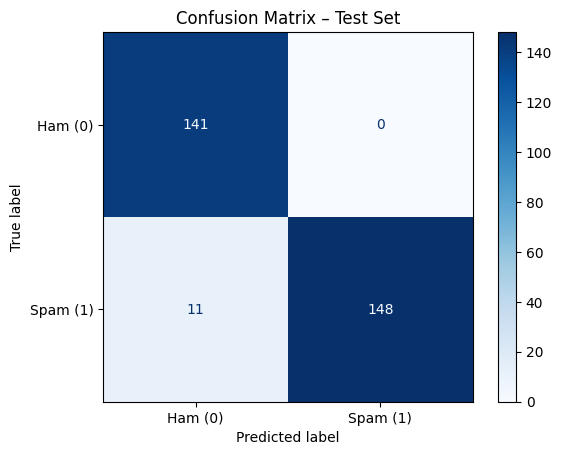

True Negative (ham→ham):   141
False Positive (ham→spam): 0
False Negative (spam→ham): 11
True Positive (spam→spam): 148

Precision (spam): 1.0000
   Recall (spam): 0.9308
       F1 (spam): 0.9642


In [ ]:
# Confusion matrix + misclassified examples
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def get_all_predictions(loader, model, device):
    model.eval()
    all_preds = []
    all_labels = []
    all_texts = []   # to show misclassified messages later

    with torch.no_grad():
        for input_batch, target_batch in loader:
            input_batch = input_batch.to(device)
            logits = model(input_batch)[:, -1, :]
            preds = torch.argmax(logits, dim=-1).cpu().numpy()
            labels = target_batch.numpy()

            all_preds.extend(preds)
            all_labels.extend(labels)


    return np.array(all_preds), np.array(all_labels)


# Get predictions on full test set
test_preds, test_true = get_all_predictions(test_loader, model, device)

# Confusion matrix
cm = confusion_matrix(test_true, test_preds, labels=[0, 1])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham (0)", "Spam (1)"]
)

plt.figure(figsize=(6, 5))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix – Test Set")
plt.grid(False)
plt.show()

# Basic counts
tn, fp, fn, tp = cm.ravel()
print(f"True Negative (ham→ham):   {tn}")
print(f"False Positive (ham→spam): {fp}")
print(f"False Negative (spam→ham): {fn}")
print(f"True Positive (spam→spam): {tp}")
print()
print(f"Precision (spam): {tp / (tp + fp):.4f}" if (tp + fp) > 0 else "Precision (spam): N/A")
print(f"   Recall (spam): {tp / (tp + fn):.4f}" if (tp + fn) > 0 else "Recall (spam): N/A")
print(f"       F1 (spam): {(2 * tp) / (2 * tp + fp + fn):.4f}" if (2 * tp + fp + fn) > 0 else "F1 (spam): N/A")

In [ ]:
from copy import deepcopy

print("=== Frozen vs Full fine-tuning comparison ===\n")


# Shared setup – reload fresh pretrained base model
print("Loading fresh GPT-2 small checkpoint for fair comparison...")

MODEL_CHOICE = "gpt2-small (124M)"

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
}
BASE_CONFIG = {
    "vocab_size": 50257,
    "context_length": 1024,
    "drop_rate": 0.0,
    "qkv_bias": True
}
BASE_CONFIG.update(model_configs[MODEL_CHOICE])

# Download / load weights once
model_size = MODEL_CHOICE.split(" ")[-1].strip("()")
_, params = download_and_load_gpt2(model_size=model_size, models_dir="gpt2_weights")

# Case 1: Selective freezing
print("\n[1/2] Training with SELECTIVE FREEZING")

model_frozen = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model_frozen, params)
model_frozen.out_head = torch.nn.Linear(BASE_CONFIG["emb_dim"], 2, bias=False)
model_frozen.to(device)

# Freeze everything
for param in model_frozen.parameters():
    param.requires_grad = False

# Unfreeze only last block + final norm + head
for param in model_frozen.trf_blocks[-1].parameters():
    param.requires_grad = True
for param in model_frozen.final_norm.parameters():
    param.requires_grad = True

trainable_frozen = sum(p.numel() for p in model_frozen.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_frozen.parameters())

print(f"  Trainable parameters: {trainable_frozen:,} / {total_params:,} ({trainable_frozen/total_params:.2%})")

optimizer_frozen = optim.AdamW(model_frozen.parameters(), lr=5e-5, weight_decay=0.1)

start_frozen = time.time()

_, _, _, _, _ = train_classifier_simple(
    model_frozen,
    train_loader,
    val_loader,
    optimizer_frozen,
    device,
    num_epochs=5,
    eval_freq=50,
    eval_iter=5
)

end_frozen = time.time()
minutes_frozen = (end_frozen - start_frozen) / 60

test_acc_frozen = calc_accuracy_loader(test_loader, model_frozen, device)

print(f"  → Selective freezing finished in {minutes_frozen:.1f} minutes")
print(f"  Test accuracy: {test_acc_frozen*100:.2f}%")

# Save this model so you don't lose it
torch.save(model_frozen.state_dict(), "spam_classifier_selective_frozen.pth")
print("  Saved: spam_classifier_selective_frozen.pth\n")


# Case 2: Full fine-tuning
print("[2/2] Training with FULL FINE-TUNING")

model_full = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model_full, params)
model_full.out_head = torch.nn.Linear(BASE_CONFIG["emb_dim"], 2, bias=False)
model_full.to(device)

# No freezing at all
for param in model_full.parameters():
    param.requires_grad = True

trainable_full = sum(p.numel() for p in model_full.parameters())

print(f"  Trainable parameters: {trainable_full:,} / {total_params:,} (100%)")

# Usually use smaller LR for full fine-tuning to avoid instability
optimizer_full = optim.AdamW(model_full.parameters(), lr=1e-5, weight_decay=0.1)

start_full = time.time()

_, _, _, _, _ = train_classifier_simple(
    model_full,
    train_loader,
    val_loader,
    optimizer_full,
    device,
    num_epochs=5,
    eval_freq=50,
    eval_iter=5
)

end_full = time.time()
minutes_full = (end_full - start_full) / 60

test_acc_full = calc_accuracy_loader(test_loader, model_full, device)

print(f"  → Full fine-tuning finished in {minutes_full:.1f} minutes")
print(f"  Test accuracy: {test_acc_full*100:.2f}%")

# Save this one too
torch.save(model_full.state_dict(), "spam_classifier_full_ft.pth")
print("  Saved: spam_classifier_full_ft.pth\n")

# Final comparison table
print("\n" + "="*70)
print("Comparison: Selective Freezing vs Full Fine-Tuning")
print("-"*70)
print(f"{'Approach':<20} {'Trainable Params':<18} {'Test Acc':<10} {'Time (min)':<12} {'Epochs'} {'Saved as'}")
print("-"*70)
print(f"{'Selective Freezing':<20} {trainable_frozen:<18,} {test_acc_frozen*100:>6.2f}%   {minutes_frozen:>8.1f}     {num_epochs}    spam_classifier_selective_frozen.pth")
print(f"{'Full Fine-Tuning':<20} {trainable_full:<18,} {test_acc_full*100:>6.2f}%   {minutes_full:>8.1f}     {num_epochs}    spam_classifier_full_ft.pth")
print("="*70)

print("\nQuick conclusion:")
acc_delta = test_acc_full - test_acc_frozen

if acc_delta > 0.01:
    print(f"→ Full fine-tuning outperforms selective freezing by {acc_delta*100:.2f}%.")
    print("  Trade-off: longer training time and higher risk of overfitting on small datasets.")
elif acc_delta < -0.01:
    print(f"→ Selective freezing outperforms full fine-tuning by {abs(acc_delta)*100:.2f}%.")
    print("  Likely reason: less overfitting — the frozen backbone acts as a regulariser.")
else:
    print(f"→ Performance is nearly identical (Δ {acc_delta*100:.2f}%).")
    print("  Selective freezing is the pragmatic choice: fewer trainable params, faster training,")
    print("  lower memory footprint, and reduced overfitting risk.")

=== Frozen vs Full fine-tuning comparison ===

Loading fresh GPT-2 small checkpoint for fair comparison...
File already exists and is up-to-date: gpt2_weights/124M/checkpoint
File already exists and is up-to-date: gpt2_weights/124M/encoder.json
File already exists and is up-to-date: gpt2_weights/124M/hparams.json
File already exists and is up-to-date: gpt2_weights/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2_weights/124M/model.ckpt.index
File already exists and is up-to-date: gpt2_weights/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2_weights/124M/vocab.bpe

[1/2] Training with SELECTIVE FREEZING
  Trainable parameters: 7,089,408 / 124,441,344 (5.70%)
Ep 01 (Step 000000): Train loss 5.894 | Val loss 4.958
Ep 01 (Step 000050): Train loss 0.647 | Val loss 0.677
Ep 01 (Step 000100): Train loss 0.591 | Val loss 0.571
Epoch 01 accuracy → Train: 0.675 | Val: 0.875
Ep 02 (Step 000150): Train loss 0.531 | Val loss 0.498
Ep 02 (Step 000200): 